In [1]:
from telescope import *
from spectrograph import *
from detector import *
from spectralmodels import Sky, get_list_of_stellar_models, get_stellar_spectrum
from etc.etc import simulate_1D_spectrum, simulate_2D_spectrum, SpecETC

import numpy as np
from matplotlib import pyplot as plt

IMX183: Reading detector efficiency from /Users/jwalawender/git/SpecETC/data/SonyIMX/QE.csv
IMX533: Reading detector efficiency from /Users/jwalawender/git/SpecETC/data/SonyIMX/QE.csv


In [2]:
models = get_list_of_stellar_models(verbose=True)
sptype = 'F8V'
mag = 10
star = get_stellar_spectrum(sptype=sptype, mag=mag)
sky = Sky(seeing=3.0*u.arcsec, mag=18)

O ['O9V', 'O8III', 'O5V']
B ['B1-2III', 'B8I', 'B9III', 'B5III', 'B5II', 'B2IV', 'B6IV', 'B5-7V', 'B2II', 'B0I', 'B1V', 'B0V', 'B8V', 'B5I', 'B3V']
A ['A0IV', 'A2V', 'A0V', 'A0III', 'A3V', 'A0I', 'A4-7IV', 'A5V', 'A5III']
F ['F2II', 'F5V', 'F8IV', 'F5III', 'F5IV', 'F2V', 'F0-2IV', 'F5I', 'F0II', 'F8V', 'F8I', 'F0I', 'F0V', 'F0III']
G ['G8III', 'G0IV', 'G8I', 'G2V', 'G8V', 'G2IV', 'G0III', 'G5IV', 'G0I', 'G5V', 'G5II', 'G0V', 'G8IV', 'G5III', 'G5I']
K ['K0-1II', 'K0III', 'K3III', 'K2V', 'K0IV', 'K2I', 'K5V', 'K7V', 'K0V', 'K3IV', 'K5III', 'K4I', 'K1IV', 'K3-4II']
M ['M0V', 'M4V', 'M2I', 'M5V', 'M3II', 'M2V', 'M5III', 'M0III', 'M10III']


In [3]:
StarEx600 = Spectrograph('StarEx600', 32*u.micron, 75*u.mm, 75*u.mm/3.5,
                         27.2*u.deg, 600/u.mm, 25*u.mm, 75*u.mm, 75*u.mm/3.5, 0.25,
                         cwav=5800*u.Angstrom)
StarEx600.grating.alpha-StarEx600.grating.beta(StarEx600.cwav) - 33.4*u.deg

<Quantity 0.06331764 deg>

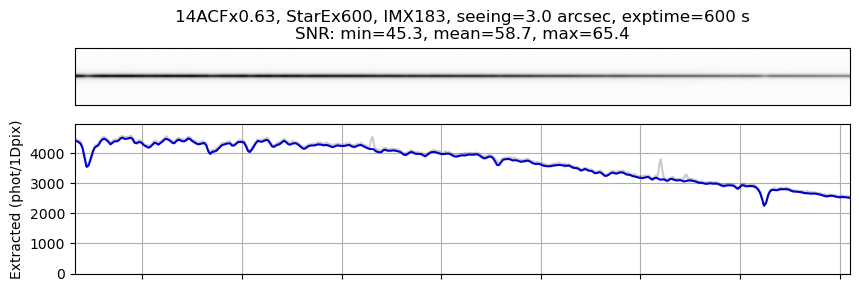

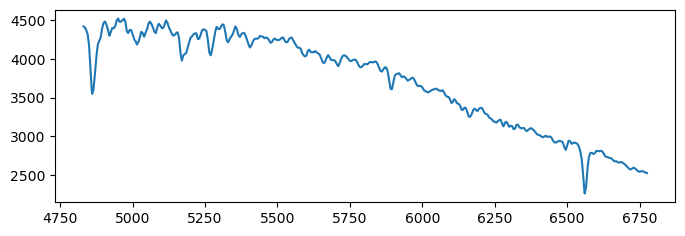

In [4]:
IMX183.exptime = 600*u.second

im, spec, var = SpecETC(star, sky, ACF14reduced, StarEx600, IMX183, plot=True)
plt.figure(figsize=(8,2.5))
plt.plot(StarEx600.binset, spec)
plt.show()

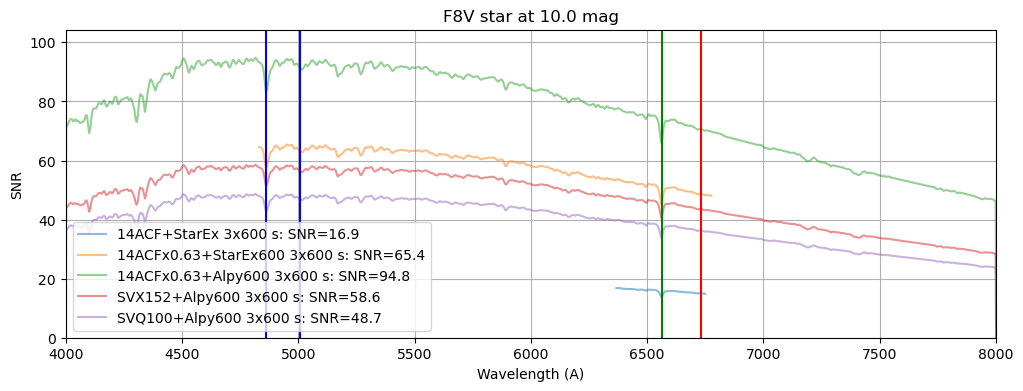

In [6]:
instrumentation = [(ACF14, StarEx, IMX183, 600*u.second, 3),
                   (ACF14reduced, StarEx600, IMX183, 600*u.second, 3),
                   (ACF14reduced, Alpy600, IMX183, 600*u.second, 3),
                   (SVX152, Alpy600, IMX183, 600*u.second, 3),
                   (SVQ100, Alpy600, IMX183, 600*u.second, 3),
                   # (SV102ABV, Alpy600, IMX183, 600*u.second, 3),
                  ]

plt.figure(figsize=(12,4))
plt.title(f'{sptype} star at {mag:.1f} mag')
peakSNR = 0

for inst in instrumentation:
    tel, spec, det, exptime, nexp = inst
    det.exptime = exptime
    im, spectra, variance = SpecETC(star, sky, tel, spec, det, plot=False)

    SNR = spectra/variance**0.5
    label = f"{tel.name}+{spec.name} {nexp:d}x{det.exptime:.0f}: SNR={max(SNR):.1f}"
    plt.plot(spec.binset, SNR, alpha=0.5, label=label)
    peakSNR = peakSNR if max(SNR) <= peakSNR else max(SNR)

plt.axvline(5007, color='b')
plt.axvline(4860, color='b')
plt.axvline(6563, color='g')
plt.axvline(6731, color='r')
plt.ylabel('SNR')
plt.xlabel('Wavelength (A)')
plt.xlim(4000, 8000)
plt.ylim(0,1.1*peakSNR)
plt.grid()
plt.legend(loc='best')
plt.show()